# Code trying a set of beta choices for duration models before large simulations

## CoMix3

0
1
2


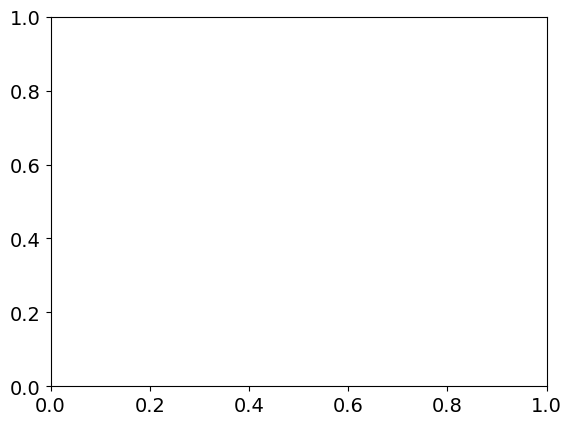

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import nd_python_avon as nd_p 
import numpy as np
import json
import sklearn.mixture
import math
import matplotlib.pyplot as plt

n = 10_000
num_networks= 1

taus = np.arange(0.1,1,0.3)

buckets = np.array([5,12,18,30,40,50,60,70])
partitions = [0.058*n, 0.145*n, 0.212*n, 0.364*n, 0.497*n, 0.623*n, 0.759*n, 0.866*n, n]

per_partition = [a if i == 0 else a-partitions[i-1] for i, a in enumerate(partitions)]

bucket_labels = ['0-4', '5-11', '12-17', '18-29', '30-39', '40-49', '50-59', '60-69', '70+']
duration_labels = ['0-1 hour', '1-4 hours', '4+ hours']
datas = ['comix3']


for i, data in enumerate(datas):
    with open(f'data/gmm_opt_comp/optimal_components_{data}_log_smalldur.json', 'r') as f:
        optimal_num_components = json.load(f)
    ##################### read fits ####################################
    with open(f'../input_data/egos/{data}_dur_small.json', 'r') as f:
        egos = json.load(f)

    for k in range(num_networks):
        samples_for_plot = []
        classifier = []
        samples = []
        for l, _ in enumerate(partitions):
            samples_for_plot.append([])
            classifier.append(sklearn.mixture.GaussianMixture(n_components=optimal_num_components[data][l], covariance_type='full'))
            egos_age = [a for a in egos if a['age'] == l]
            ## use log(k+1) instead of k to fit
            X = [[math.log(b+1) for b in a['contacts']] for a in egos_age]
            classifier[l].fit(X)
            ## sample same number of people as the data
            samples_tmp,_ = classifier[l].sample(per_partition[l])
            for sample in samples_tmp:
                samples.append([int(np.round(np.exp(b)-1)) if int(np.round(np.exp(b)-1))>=0 else 0 for b in sample])
                samples_for_plot[-1].append([int(np.round(np.exp(b)-1)) if int(np.round(np.exp(b)-1))>=0 else 0 for b in sample])
        res = nd_p.gmm_dur(samples,partitions=partitions,num_dur=3, taus=taus, iterations=5)

In [9]:
print(res['avg_d_input']/n)
print(res['avg_d_network'])

4.0247
[2.9138, 2.9108, 2.917]


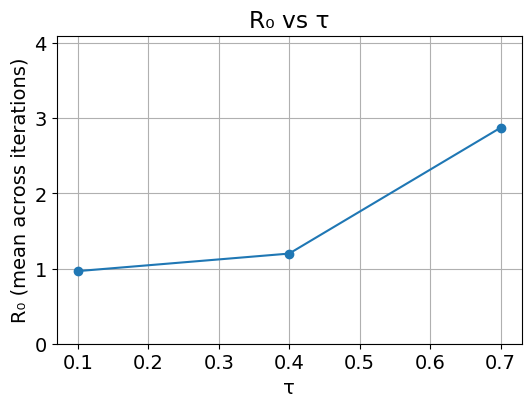

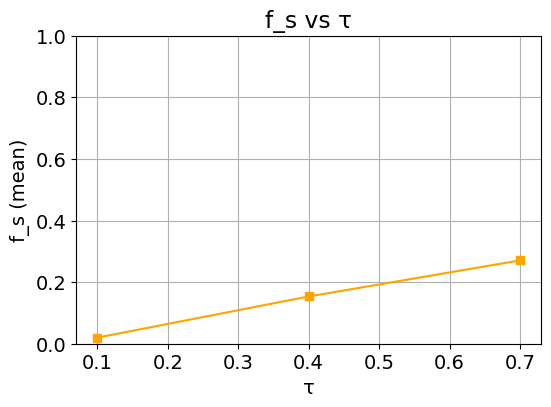

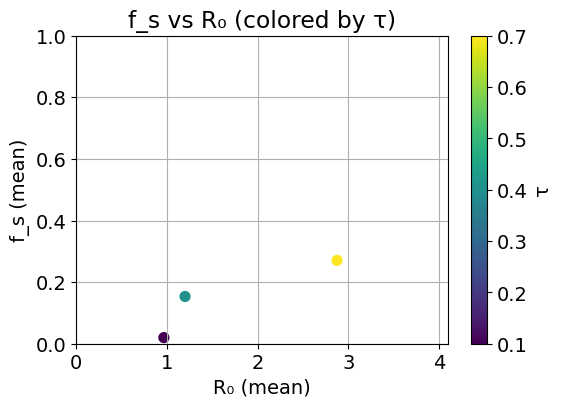

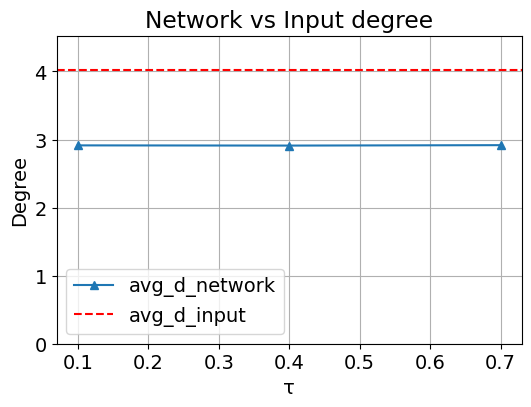

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Extract from your dictionary
taus = np.array(res["taus"])
r0 = np.array(res["r0"])           # shape (len(taus), iterations)
fs = np.array(res["fs"])           # shape (len(taus), iterations)
avg_d_network = np.array(res["avg_d_network"])
avg_d_input = res["avg_d_input"]/n   # scalar

# Average across iterations
r0_mean = [np.mean([b for b in a if b>0]) for a in r0]
fs_mean = [np.mean([b for b in a if b>0]) for a in fs]

# 1) R0 vs taus
plt.figure(figsize=(6,4))
plt.plot(taus, r0_mean, marker='o')
plt.xlabel("τ")
plt.ylabel("R₀ (mean across iterations)")
plt.title("CoMix3: R₀ vs τ")
plt.ylim(0, 4.1)
plt.grid(True)
plt.show()

# 2) fs vs taus
plt.figure(figsize=(6,4))
plt.plot(taus, fs_mean, marker='s', color='orange')
plt.xlabel("τ")
plt.ylabel("f_s (mean)")
plt.title("CoMix3: f_s vs τ")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

# 3) fs vs R0
plt.figure(figsize=(6,4))
plt.scatter(r0_mean, fs_mean, c=taus, cmap="viridis", s=50)
plt.colorbar(label="τ")
plt.xlabel("R₀ (mean)")
plt.ylabel("f_s (mean)")
plt.title("CoMix3: f_s vs R₀ (colored by τ)")
plt.xlim(0, 4.1)
plt.ylim(0, 1)
plt.grid(True)
plt.show()

# 4) avg_d_network vs avg_d_input
plt.figure(figsize=(6,4))
plt.plot(taus, avg_d_network, marker='^', label="avg_d_network")
plt.axhline(y=avg_d_input, color='red', linestyle='--', label="avg_d_input")
plt.xlabel("τ")
plt.ylabel("Degree")
plt.title("CoMix3: Network vs Input degree")
plt.ylim(0, max(max(avg_d_network), avg_d_input) + .5)
plt.legend()
plt.grid(True)
plt.show()


## CoMixa

In [ ]:
print(res['avg_d_input']/n)
print(res['avg_d_network'])

4.0247
[2.9138, 2.9108, 2.917]


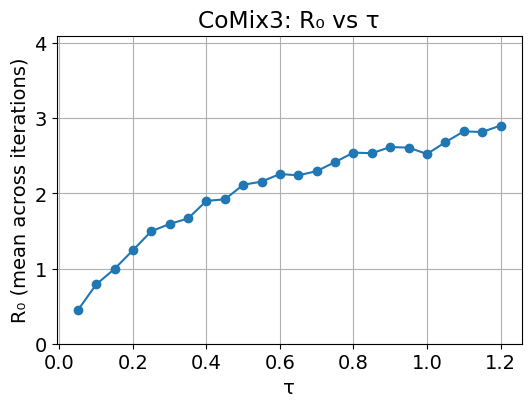

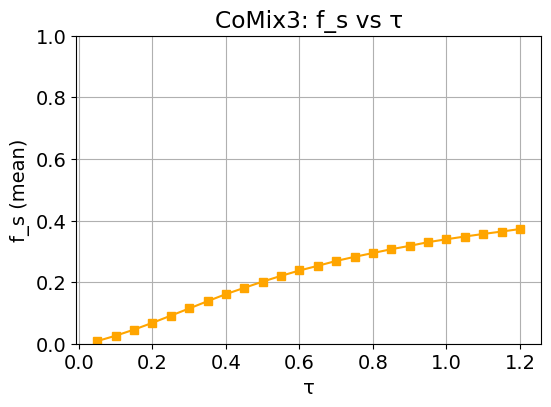

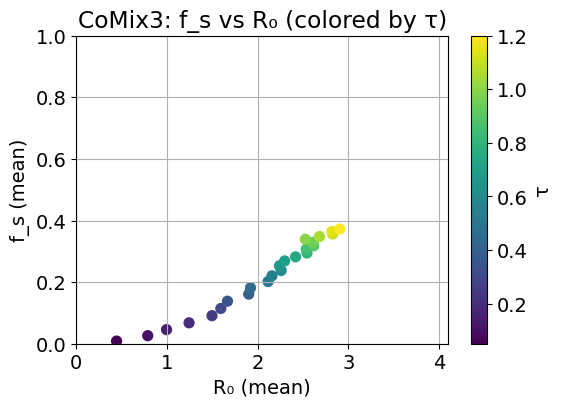

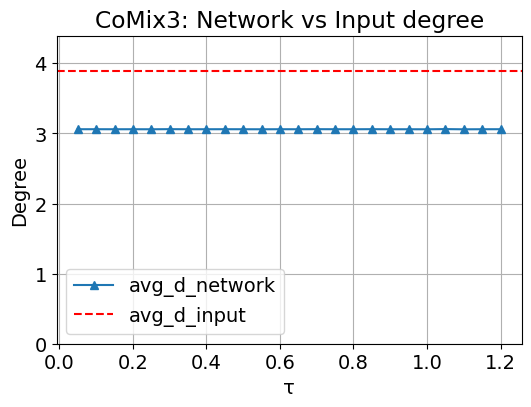

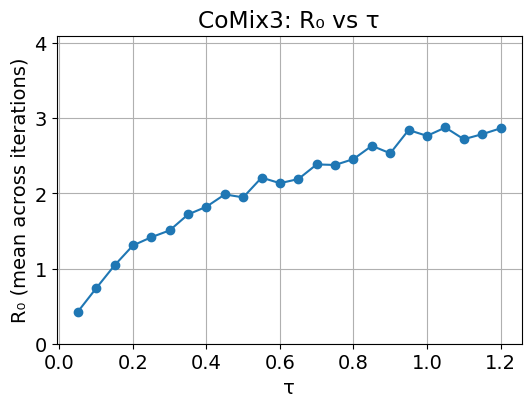

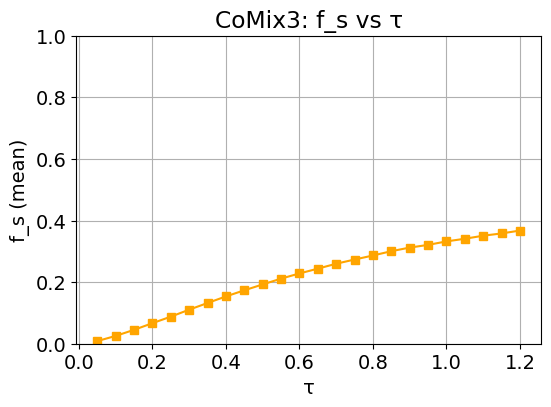

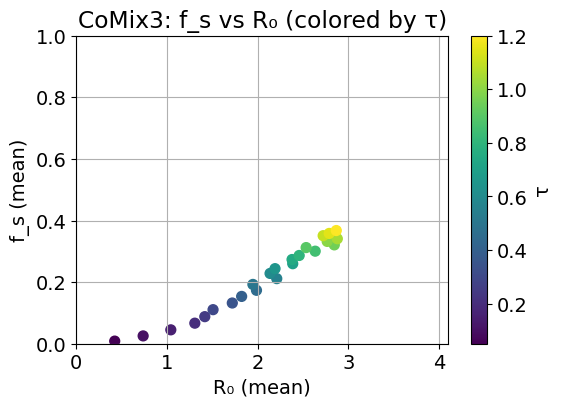

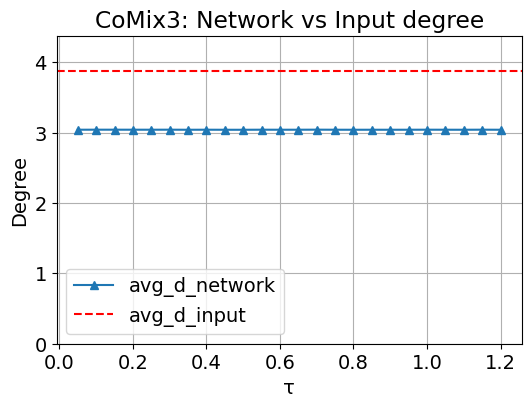

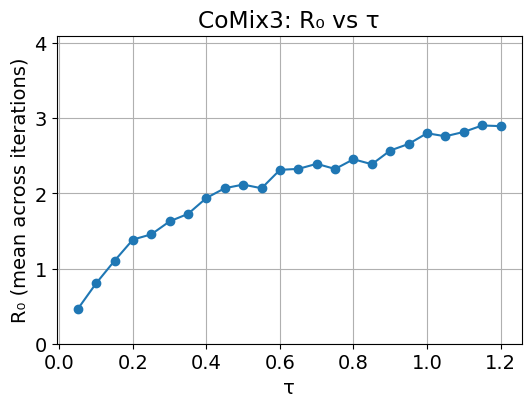

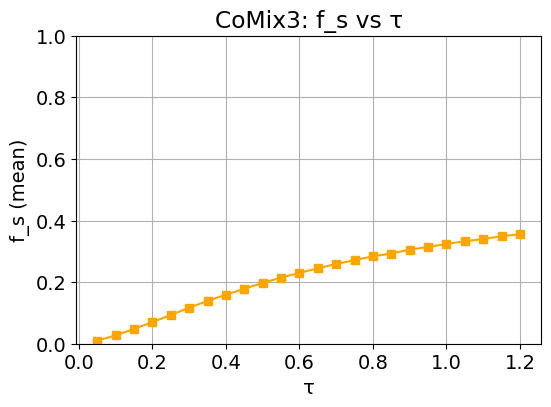

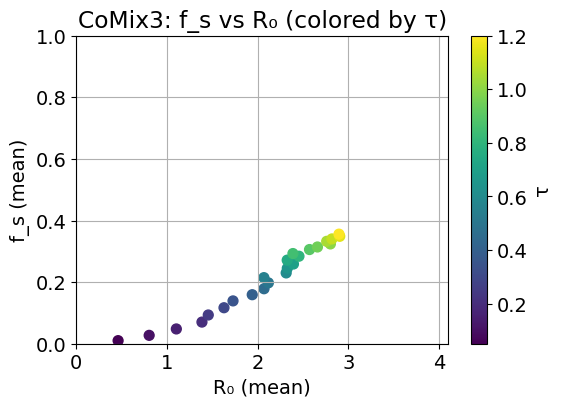

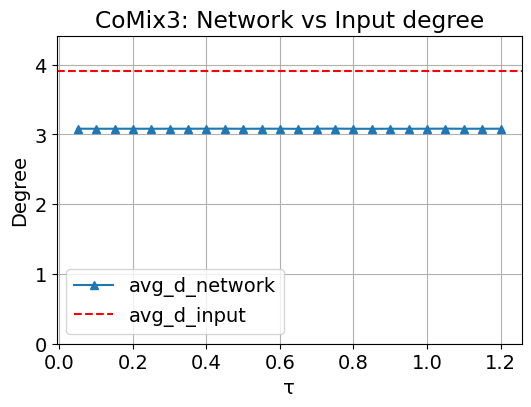

In [15]:
import numpy as np
import matplotlib.pyplot as plt

for k in range(3):
    with open(f'sims/comix3_{k}.json', 'r') as f:
        res = json.load(f)


    n=100_000
    # Extract from your dictionary
    taus = np.array(res["taus"])
    r0 = np.array(res["r0"])           # shape (len(taus), iterations)
    fs = np.array(res["fs"])           # shape (len(taus), iterations)
    avg_d_network = np.array(res["avg_d_network"])
    avg_d_input = res["avg_d_input"]/n   # scalar

    # Average across iterations
    r0_mean = [np.mean([b for b in a if b>0]) for a in r0]
    fs_mean = [np.mean([b for b in a if b>0]) for a in fs]

    # 1) R0 vs taus
    plt.figure(figsize=(6,4))
    plt.plot(taus, r0_mean, marker='o')
    plt.xlabel("τ")
    plt.ylabel("R₀ (mean across iterations)")
    plt.title("CoMix3: R₀ vs τ")
    plt.ylim(0, 4.1)
    plt.grid(True)
    plt.show()

    # 2) fs vs taus
    plt.figure(figsize=(6,4))
    plt.plot(taus, fs_mean, marker='s', color='orange')
    plt.xlabel("τ")
    plt.ylabel("f_s (mean)")
    plt.title("CoMix3: f_s vs τ")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.show()

    # 3) fs vs R0
    plt.figure(figsize=(6,4))
    plt.scatter(r0_mean, fs_mean, c=taus, cmap="viridis", s=50)
    plt.colorbar(label="τ")
    plt.xlabel("R₀ (mean)")
    plt.ylabel("f_s (mean)")
    plt.title("CoMix3: f_s vs R₀ (colored by τ)")
    plt.xlim(0, 4.1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.show()

    # 4) avg_d_network vs avg_d_input
    plt.figure(figsize=(6,4))
    plt.plot(taus, avg_d_network, marker='^', label="avg_d_network")
    plt.axhline(y=avg_d_input, color='red', linestyle='--', label="avg_d_input")
    plt.xlabel("τ")
    plt.ylabel("Degree")
    plt.title("CoMix3: Network vs Input degree")
    plt.ylim(0, max(max(avg_d_network), avg_d_input) + .5)
    plt.legend()
    plt.grid(True)
    plt.show()
